In [1]:
# ============================================================
# PHASE 15 — CELL 1
# Imports
# ============================================================

import os
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Imports successful.")

Imports successful.


In [2]:
# ============================================================
# PHASE 15 — CELL 2
# Project root
# ============================================================

PROJECT_ROOT = Path(
    r"D:\downloads\misleading-health-infographic-detection"
)

assert PROJECT_ROOT.exists(), "Project root does not exist."

print("Project root:")
print(PROJECT_ROOT)

print("\n✓ Project root verified.")

Project root:
D:\downloads\misleading-health-infographic-detection

✓ Project root verified.


In [3]:
# ============================================================
# PHASE 15 — CELL 3
# Output directories
# ============================================================

PHASE15_DIR = PROJECT_ROOT / "outputs" / "phase15"

EXPLANATIONS_DIR = PHASE15_DIR / "explanations"
MANIFEST_DIR = PHASE15_DIR / "manifests"
METRICS_DIR = PHASE15_DIR / "metrics"
VIS_DIR = PHASE15_DIR / "visualizations"
REPORTS_DIR = PHASE15_DIR / "reports"

for directory in [
    PHASE15_DIR,
    EXPLANATIONS_DIR,
    MANIFEST_DIR,
    METRICS_DIR,
    VIS_DIR,
    REPORTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Phase 15 directories created.")
print(PHASE15_DIR)

Phase 15 directories created.
D:\downloads\misleading-health-infographic-detection\outputs\phase15


In [4]:
# ============================================================
# PHASE 15 — CELL 4
# Load Phase 14 explainability input
# ============================================================

PHASE14_INPUT = (
    PROJECT_ROOT
    / "outputs"
    / "phase14"
    / "manifests"
    / "phase15_explainability_input.csv"
)

assert PHASE14_INPUT.exists(), (
    f"Phase 14 input not found:\n{PHASE14_INPUT}"
)

df = pd.read_csv(PHASE14_INPUT)

print("Phase 14 input loaded.")
print("Shape:", df.shape)

display(df.head())

Phase 14 input loaded.
Shape: (70, 15)


,claim_id,record_key,image_path,label,source,phase11_split,claim_text,claim_type,topics,evidence_source,evidence_id,evidence_title,evidence_text,evidence_url,evidence_score
0,claim13b_000000,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,"The purpose of this campaign is, ""to help redu...",unknown,"[""other""]",PubMed,36951564,COVID-19 vaccine booster dose hesitancy among ...,Vaccination is an important tool for controlli...,https://pubmed.ncbi.nlm.nih.gov/36951564/,0.8571
1,claim13b_000000,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,"The purpose of this campaign is, ""to help redu...",unknown,"[""other""]",PubMed,12170548,[National preparedness for biological mass cas...,"Species of plants and animals, as well as nati...",https://pubmed.ncbi.nlm.nih.gov/12170548/,0.8571
2,claim13b_000000,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,"The purpose of this campaign is, ""to help redu...",unknown,"[""other""]",PubMed,37084298,Using the increasing vaccination model and the...,COVID-19 vaccination programmes have helped re...,https://pubmed.ncbi.nlm.nih.gov/37084298/,0.7143
3,claim13b_000000,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,"The purpose of this campaign is, ""to help redu...",unknown,"[""other""]",PubMed,36302397,Vaccination Trends and Family-Level Characteri...,Assess family-level factors associated with ch...,https://pubmed.ncbi.nlm.nih.gov/36302397/,0.4286
4,claim13b_000000,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,"The purpose of this campaign is, ""to help redu...",unknown,"[""other""]",WHO,7ebd5eb146705ea5,Global,NaN,https://www.who.int/,0.0000


In [5]:
# ============================================================
# PHASE 15 — CELL 5
# Inspect input columns
# ============================================================

print("Columns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

Columns:
01. claim_id
02. record_key
03. image_path
04. label
05. source
06. phase11_split
07. claim_text
08. claim_type
09. topics
10. evidence_source
11. evidence_id
12. evidence_title
13. evidence_text
14. evidence_url
15. evidence_score


In [6]:
# ============================================================
# PHASE 15 — CELL 6
# Validate required columns
# ============================================================

REQUIRED_COLUMNS = [
    "claim_id",
    "record_key",
    "image_path",
    "label",
    "source",
    "phase11_split",
    "claim_text",
    "claim_type",
    "evidence_source",
    "evidence_id",
    "evidence_title",
    "evidence_text",
    "evidence_url",
    "evidence_score",
]

missing_columns = [
    column for column in REQUIRED_COLUMNS
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("✓ All required Phase 15 columns are present.")

✓ All required Phase 15 columns are present.


In [7]:
# ============================================================
# PHASE 15 — CELL 7
# Clean input data
# ============================================================

TEXT_COLUMNS = [
    "claim_text",
    "claim_type",
    "evidence_source",
    "evidence_title",
    "evidence_text",
    "evidence_url",
]

for column in TEXT_COLUMNS:
    df[column] = (
        df[column]
        .fillna("")
        .astype(str)
        .str.strip()
    )

df["evidence_score"] = pd.to_numeric(
    df["evidence_score"],
    errors="coerce"
).fillna(0.0)

print("Cleaning complete.")
print("Rows:", len(df))

Cleaning complete.
Rows: 70


In [8]:
# ============================================================
# PHASE 15 — CELL 8
# Evidence coverage
# ============================================================

coverage = (
    df.groupby("claim_id")
    .agg(
        evidence_count=("evidence_id", "count"),
        best_evidence_score=("evidence_score", "max"),
        evidence_sources=(
            "evidence_source",
            lambda x: ", ".join(sorted(set(
                str(v) for v in x if str(v).strip()
            )))
        ),
    )
    .reset_index()
)

print("Claims:", coverage["claim_id"].nunique())
print(
    "Claims with evidence:",
    (coverage["evidence_count"] > 0).sum()
)

display(coverage)

Claims: 14
Claims with evidence: 14


,claim_id,evidence_count,best_evidence_score,evidence_sources
0,claim13b_000000,5,0.8571,"PubMed, WHO"
1,claim13b_000001,5,0.0000,WHO
2,claim13b_000002,5,0.7500,PubMed
3,claim13b_000003,5,0.0000,WHO
4,claim13b_000004,5,0.0000,WHO
5,claim13b_000005,5,1.0000,PubMed
6,claim13b_000006,5,0.7500,PubMed
7,claim13b_000007,5,0.8571,"PubMed, WHO"
8,claim13b_000008,5,0.0000,WHO
9,claim13b_000009,5,0.7500,PubMed


In [9]:
# ============================================================
# PHASE 15 — CELL 9
# Text normalization
# ============================================================

def normalize_text(text):
    text = str(text)

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    text = re.sub(
        r"\s+([,.!?;:])",
        r"\1",
        text
    )

    return text.strip()


df["claim_text_clean"] = (
    df["claim_text"]
    .apply(normalize_text)
)

df["evidence_title_clean"] = (
    df["evidence_title"]
    .apply(normalize_text)
)

df["evidence_text_clean"] = (
    df["evidence_text"]
    .apply(normalize_text)
)

print("Text normalization complete.")

Text normalization complete.


In [10]:
# ============================================================
# PHASE 15 — CELL 10
# Token extraction
# ============================================================

STOPWORDS = {
    "the", "and", "for", "that", "this",
    "with", "from", "are", "was", "were",
    "has", "have", "had", "into", "their",
    "there", "than", "then", "they",
    "them", "you", "your", "our",
    "can", "may", "might", "could",
    "should", "would", "about",
    "these", "those", "which",
    "while", "where", "when",
    "what", "who", "how",
    "not", "but", "also",
    "all", "any", "some",
    "more", "most", "other",
}

def tokenize(text):
    tokens = re.findall(
        r"[a-zA-Z]{3,}",
        str(text).lower()
    )

    return {
        token
        for token in tokens
        if token not in STOPWORDS
    }


def get_overlap_terms(claim_text, evidence_text):
    claim_tokens = tokenize(claim_text)
    evidence_tokens = tokenize(evidence_text)

    return sorted(
        claim_tokens & evidence_tokens
    )


df["overlap_terms"] = df.apply(
    lambda row: get_overlap_terms(
        row["claim_text_clean"],
        (
            row["evidence_title_clean"]
            + " "
            + row["evidence_text_clean"]
        )
    ),
    axis=1
)

df["overlap_count"] = (
    df["overlap_terms"]
    .apply(len)
)

print("Overlap analysis complete.")

Overlap analysis complete.


In [11]:
# ============================================================
# PHASE 15 — CELL 11
# Evidence relevance classification
# ============================================================

def classify_relevance(score):
    score = float(score)

    if score >= 0.60:
        return "HIGH_RELEVANCE"

    elif score >= 0.30:
        return "MODERATE_RELEVANCE"

    elif score > 0:
        return "LOW_RELEVANCE"

    return "NO_TEXTUAL_EVIDENCE"


df["evidence_relevance"] = (
    df["evidence_score"]
    .apply(classify_relevance)
)

print(
    df["evidence_relevance"]
    .value_counts()
)

evidence_relevance
NO_TEXTUAL_EVIDENCE    32
HIGH_RELEVANCE         24
MODERATE_RELEVANCE     14
Name: count, dtype: int64


In [12]:
# ============================================================
# PHASE 15 — CELL 12
# Generate evidence explanations
# ============================================================

def build_explanation(row):

    claim = row["claim_text_clean"]
    source = row["evidence_source"]
    title = row["evidence_title_clean"]
    score = float(row["evidence_score"])

    overlap_terms = row["overlap_terms"]

    if isinstance(overlap_terms, str):
        try:
            overlap_terms = json.loads(overlap_terms)
        except:
            overlap_terms = []

    if not isinstance(overlap_terms, list):
        overlap_terms = []

    if score >= 0.60:
        relevance_description = (
            "The retrieved evidence has high textual relevance "
            "to the extracted claim."
        )

    elif score >= 0.30:
        relevance_description = (
            "The retrieved evidence has moderate textual relevance "
            "to the extracted claim."
        )

    elif score > 0:
        relevance_description = (
            "The retrieved evidence has limited textual overlap "
            "with the extracted claim."
        )

    else:
        relevance_description = (
            "No meaningful textual overlap was detected "
            "by the retrieval relevance measure."
        )

    if overlap_terms:
        overlap_text = ", ".join(
            overlap_terms[:10]
        )

        relationship = (
            f"The claim and retrieved evidence share "
            f"medical/topic terms including: {overlap_text}."
        )
    else:
        relationship = (
            "No major shared content terms were identified "
            "by the lexical comparison."
        )

    explanation = (
        f"Claim: {claim}\n\n"
        f"Retrieved source: {source}\n"
        f"Evidence title: {title}\n\n"
        f"{relevance_description}\n"
        f"{relationship}\n\n"
        f"Important limitation: this explanation describes "
        f"retrieval relevance and does not independently establish "
        f"whether the medical claim is true or false."
    )

    return explanation


df["explanation"] = df.apply(
    build_explanation,
    axis=1
)

print("Explanations generated.")

display(
    df[
        [
            "claim_id",
            "claim_text",
            "evidence_source",
            "evidence_score",
            "explanation",
        ]
    ].head(3)
)

Explanations generated.


,claim_id,claim_text,evidence_source,evidence_score,explanation
0,claim13b_000000,"The purpose of this campaign is, ""to help redu...",PubMed,0.8571,"Claim: The purpose of this campaign is, ""to he..."
1,claim13b_000000,"The purpose of this campaign is, ""to help redu...",PubMed,0.8571,"Claim: The purpose of this campaign is, ""to he..."
2,claim13b_000000,"The purpose of this campaign is, ""to help redu...",PubMed,0.7143,"Claim: The purpose of this campaign is, ""to he..."


In [13]:
# ============================================================
# PHASE 15 — CELL 13
# Explanation category
# ============================================================

def explanation_category(row):

    score = float(row["evidence_score"])

    if score >= 0.60:
        return "STRONGLY_RELEVANT_RETRIEVAL"

    elif score >= 0.30:
        return "RELEVANT_RETRIEVAL"

    elif score > 0:
        return "WEAK_RETRIEVAL"

    return "NO_RETRIEVAL_MATCH"


df["explanation_category"] = df.apply(
    explanation_category,
    axis=1
)

print(
    df["explanation_category"]
    .value_counts()
)

explanation_category
NO_RETRIEVAL_MATCH             32
STRONGLY_RELEVANT_RETRIEVAL    24
RELEVANT_RETRIEVAL             14
Name: count, dtype: int64


In [15]:
# ============================================================
# PHASE 15 — CELL 14
# Claim-level explainability
# ============================================================

claim_explanations = []

for claim_id, group in df.groupby("claim_id"):

    group = group.sort_values(
        "evidence_score",
        ascending=False
    )

    first = group.iloc[0]

    evidence_items = []

    for _, row in group.iterrows():

        overlap_terms = row["overlap_terms"]

        # Make sure overlap_terms is a list
        if isinstance(overlap_terms, str):
            try:
                overlap_terms = json.loads(overlap_terms)
            except Exception:
                overlap_terms = []

        if not isinstance(overlap_terms, list):
            overlap_terms = []

        evidence_items.append({
            "evidence_source": row["evidence_source"],
            "evidence_id": row["evidence_id"],
            "evidence_title": row["evidence_title"],
            "evidence_url": row["evidence_url"],
            "evidence_score": float(
                row["evidence_score"]
            ),
            "relevance": row["evidence_relevance"],
            "overlap_terms": overlap_terms,
        })

    claim_explanations.append({

        "claim_id": claim_id,

        "record_key": first["record_key"],

        "image_path": first["image_path"],

        "label": first["label"],

        "source": first["source"],

        "phase11_split": first["phase11_split"],

        "claim_text": first["claim_text"],

        "claim_type": first["claim_type"],

        "evidence_count": len(group),

        "best_evidence_score": float(
            group["evidence_score"].max()
        ),

        "evidence_sources": sorted(
            set(
                str(x)
                for x in group["evidence_source"]
                if str(x).strip()
            )
        ),

        "evidence_items": evidence_items,

        "explanation": (
            f"The extracted claim is: "
            f"{first['claim_text']}\n\n"
            f"{len(group)} retrieved evidence item(s) "
            f"were associated with this claim. "
            f"The highest textual relevance score was "
            f"{group['evidence_score'].max():.4f}.\n\n"
            f"These results indicate retrieval relevance only; "
            f"they do not independently establish the truth "
            f"or falsity of the medical claim."
        ),
    })


claim_explanations_df = pd.DataFrame(
    claim_explanations
)

print(
    "Claim-level explanations:",
    len(claim_explanations_df)
)

display(
    claim_explanations_df.head()
)

Claim-level explanations: 14


,claim_id,record_key,image_path,label,source,phase11_split,claim_text,claim_type,evidence_count,best_evidence_score,evidence_sources,evidence_items,explanation
0,claim13b_000000,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,"The purpose of this campaign is, ""to help redu...",unknown,5,0.8571,"[PubMed, WHO]","[{'evidence_source': 'PubMed', 'evidence_id': ...",The extracted claim is: The purpose of this ca...
1,claim13b_000001,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,"get the vaccine."" That is a direct quote",general_health,5,0.0000,[WHO],"[{'evidence_source': 'WHO', 'evidence_id': '7e...","The extracted claim is: get the vaccine."" That..."
2,claim13b_000002,record_000062,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,Each vial contains 5 doses of 0.5 mL,quantitative,5,0.7500,[PubMed],"[{'evidence_source': 'PubMed', 'evidence_id': ...",The extracted claim is: Each vial contains 5 d...
3,claim13b_000003,record_000062,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,No Preservative Each vial contains 5 doses of ...,quantitative,5,0.0000,[WHO],"[{'evidence_source': 'WHO', 'evidence_id': '7e...",The extracted claim is: No Preservative Each v...
4,claim13b_000004,record_000062,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,Each vial contains 5 doses of 0.5 mL Janssen C...,quantitative,5,0.0000,[WHO],"[{'evidence_source': 'WHO', 'evidence_id': '7e...",The extracted claim is: Each vial contains 5 d...


In [16]:
for _, row in claim_explanations_df.head(5).iterrows():

    print("=" * 80)

    print("CLAIM ID:")
    print(row["claim_id"])

    print("\nCLAIM:")
    print(row["claim_text"])

    print("\nCLAIM TYPE:")
    print(row["claim_type"])

    print("\nEVIDENCE COUNT:")
    print(row["evidence_count"])

    print("\nBEST RELEVANCE:")
    print(row["best_evidence_score"])

    print("\nSOURCES:")
    print(row["evidence_sources"])

    print("\nEXPLANATION:")
    print(row["explanation"])

    print()

CLAIM ID:
claim13b_000000

CLAIM:
The purpose of this campaign is, "to help reduce hesitance

CLAIM TYPE:
unknown

EVIDENCE COUNT:
5

BEST RELEVANCE:
0.8571

SOURCES:
['PubMed', 'WHO']

EXPLANATION:
The extracted claim is: The purpose of this campaign is, "to help reduce hesitance

5 retrieved evidence item(s) were associated with this claim. The highest textual relevance score was 0.8571.

These results indicate retrieval relevance only; they do not independently establish the truth or falsity of the medical claim.

CLAIM ID:
claim13b_000001

CLAIM:
get the vaccine." That is a direct quote

CLAIM TYPE:
general_health

EVIDENCE COUNT:
5

BEST RELEVANCE:
0.0

SOURCES:
['WHO']

EXPLANATION:
The extracted claim is: get the vaccine." That is a direct quote

5 retrieved evidence item(s) were associated with this claim. The highest textual relevance score was 0.0000.

These results indicate retrieval relevance only; they do not independently establish the truth or falsity of the medical clai

In [17]:
# ============================================================
# PHASE 15 — CELL 15
# Inspect claim-level explanations
# ============================================================

for _, row in claim_explanations_df.head(5).iterrows():

    print("=" * 80)

    print("CLAIM ID:")
    print(row["claim_id"])

    print("\nCLAIM:")
    print(row["claim_text"])

    print("\nCLAIM TYPE:")
    print(row["claim_type"])

    print("\nEVIDENCE COUNT:")
    print(row["evidence_count"])

    print("\nBEST RELEVANCE:")
    print(row["best_evidence_score"])

    print("\nSOURCES:")
    print(row["evidence_sources"])

    print("\nEXPLANATION:")
    print(row["explanation"])

    print()

CLAIM ID:
claim13b_000000

CLAIM:
The purpose of this campaign is, "to help reduce hesitance

CLAIM TYPE:
unknown

EVIDENCE COUNT:
5

BEST RELEVANCE:
0.8571

SOURCES:
['PubMed', 'WHO']

EXPLANATION:
The extracted claim is: The purpose of this campaign is, "to help reduce hesitance

5 retrieved evidence item(s) were associated with this claim. The highest textual relevance score was 0.8571.

These results indicate retrieval relevance only; they do not independently establish the truth or falsity of the medical claim.

CLAIM ID:
claim13b_000001

CLAIM:
get the vaccine." That is a direct quote

CLAIM TYPE:
general_health

EVIDENCE COUNT:
5

BEST RELEVANCE:
0.0

SOURCES:
['WHO']

EXPLANATION:
The extracted claim is: get the vaccine." That is a direct quote

5 retrieved evidence item(s) were associated with this claim. The highest textual relevance score was 0.0000.

These results indicate retrieval relevance only; they do not independently establish the truth or falsity of the medical clai

In [18]:
# ============================================================
# PHASE 15 — CELL 15
# Inspect claim-level explanations
# ============================================================

for _, row in claim_explanations_df.head(5).iterrows():

    print("=" * 80)

    print("CLAIM ID:")
    print(row["claim_id"])

    print("\nCLAIM:")
    print(row["claim_text"])

    print("\nCLAIM TYPE:")
    print(row["claim_type"])

    print("\nEVIDENCE COUNT:")
    print(row["evidence_count"])

    print("\nBEST RELEVANCE:")
    print(row["best_evidence_score"])

    print("\nSOURCES:")
    print(row["evidence_sources"])

    print("\nEXPLANATION:")
    print(row["explanation"])

    print()

CLAIM ID:
claim13b_000000

CLAIM:
The purpose of this campaign is, "to help reduce hesitance

CLAIM TYPE:
unknown

EVIDENCE COUNT:
5

BEST RELEVANCE:
0.8571

SOURCES:
['PubMed', 'WHO']

EXPLANATION:
The extracted claim is: The purpose of this campaign is, "to help reduce hesitance

5 retrieved evidence item(s) were associated with this claim. The highest textual relevance score was 0.8571.

These results indicate retrieval relevance only; they do not independently establish the truth or falsity of the medical claim.

CLAIM ID:
claim13b_000001

CLAIM:
get the vaccine." That is a direct quote

CLAIM TYPE:
general_health

EVIDENCE COUNT:
5

BEST RELEVANCE:
0.0

SOURCES:
['WHO']

EXPLANATION:
The extracted claim is: get the vaccine." That is a direct quote

5 retrieved evidence item(s) were associated with this claim. The highest textual relevance score was 0.0000.

These results indicate retrieval relevance only; they do not independently establish the truth or falsity of the medical clai

In [19]:
# ============================================================
# PHASE 15 — CELL 16
# Explanation quality checks
# ============================================================

def explanation_quality_flag(row):

    flags = []

    claim_text = str(row["claim_text"]).strip()
    explanation = str(row["explanation"]).lower()

    # Empty claim
    if not claim_text:
        flags.append("EMPTY_CLAIM")

    # No evidence
    if int(row["evidence_count"]) == 0:
        flags.append("NO_EVIDENCE")

    # No meaningful relevance
    if float(row["best_evidence_score"]) <= 0:
        flags.append("ZERO_RELEVANCE")

    # Detect unsupported certainty
    dangerous_phrases = [
        "proves that",
        "proven true",
        "definitely true",
        "definitely false",
        "medically confirmed",
        "scientifically proven",
        "confirmed to be true",
    ]

    for phrase in dangerous_phrases:

        if phrase in explanation:
            flags.append("OVERCLAIMING")

    return ",".join(sorted(set(flags)))


claim_explanations_df["quality_flags"] = (
    claim_explanations_df.apply(
        explanation_quality_flag,
        axis=1
    )
)

print("Quality checking complete.")

display(
    claim_explanations_df[
        [
            "claim_id",
            "evidence_count",
            "best_evidence_score",
            "quality_flags",
        ]
    ]
)

Quality checking complete.


,claim_id,evidence_count,best_evidence_score,quality_flags
0,claim13b_000000,5,0.8571,
1,claim13b_000001,5,0.0000,ZERO_RELEVANCE
2,claim13b_000002,5,0.7500,
3,claim13b_000003,5,0.0000,ZERO_RELEVANCE
4,claim13b_000004,5,0.0000,ZERO_RELEVANCE
5,claim13b_000005,5,1.0000,
6,claim13b_000006,5,0.7500,
7,claim13b_000007,5,0.8571,
8,claim13b_000008,5,0.0000,ZERO_RELEVANCE
9,claim13b_000009,5,0.7500,


In [20]:
# ============================================================
# PHASE 15 — CELL 17
# Quality issue summary
# ============================================================

quality_summary = {
    "total_claims": len(claim_explanations_df),

    "empty_claims": (
        claim_explanations_df["quality_flags"]
        .str.contains(
            "EMPTY_CLAIM",
            na=False
        )
    ).sum(),

    "claims_without_evidence": (
        claim_explanations_df["quality_flags"]
        .str.contains(
            "NO_EVIDENCE",
            na=False
        )
    ).sum(),

    "zero_relevance_claims": (
        claim_explanations_df["quality_flags"]
        .str.contains(
            "ZERO_RELEVANCE",
            na=False
        )
    ).sum(),

    "overclaiming_explanations": (
        claim_explanations_df["quality_flags"]
        .str.contains(
            "OVERCLAIMING",
            na=False
        )
    ).sum(),
}

quality_summary_df = pd.DataFrame(
    [quality_summary]
)

display(quality_summary_df)

,total_claims,empty_claims,claims_without_evidence,zero_relevance_claims,overclaiming_explanations
0,14,0,0,6,0


In [21]:
# ============================================================
# PHASE 15 — CELL 18
# Save claim-level explanations CSV
# ============================================================

CLAIM_EXPLANATIONS_CSV = (
    MANIFEST_DIR
    / "claim_level_explanations.csv"
)

claim_explanations_export = (
    claim_explanations_df.copy()
)

# Convert list/dictionary fields into JSON strings
claim_explanations_export[
    "evidence_sources"
] = claim_explanations_export[
    "evidence_sources"
].apply(
    lambda x: json.dumps(
        x,
        ensure_ascii=False
    )
)

claim_explanations_export[
    "evidence_items"
] = claim_explanations_export[
    "evidence_items"
].apply(
    lambda x: json.dumps(
        x,
        ensure_ascii=False
    )
)

claim_explanations_export.to_csv(
    CLAIM_EXPLANATIONS_CSV,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(CLAIM_EXPLANATIONS_CSV)

print(
    "Rows:",
    len(claim_explanations_export)
)

Saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase15\manifests\claim_level_explanations.csv
Rows: 14


In [22]:
# ============================================================
# PHASE 15 — CELL 19
# Save evidence-level explanations
# ============================================================

EVIDENCE_EXPLANATIONS_CSV = (
    MANIFEST_DIR
    / "evidence_level_explanations.csv"
)

evidence_export_columns = [
    "claim_id",
    "record_key",
    "image_path",
    "label",
    "source",
    "phase11_split",
    "claim_text",
    "claim_type",
    "evidence_source",
    "evidence_id",
    "evidence_title",
    "evidence_text",
    "evidence_url",
    "evidence_score",
    "evidence_relevance",
    "overlap_terms",
    "overlap_count",
    "explanation_category",
    "explanation",
]

# Check columns first
missing_export_columns = [
    c
    for c in evidence_export_columns
    if c not in df.columns
]

if missing_export_columns:
    raise ValueError(
        f"Missing columns: {missing_export_columns}"
    )

evidence_export = df[
    evidence_export_columns
].copy()

evidence_export[
    "overlap_terms"
] = evidence_export[
    "overlap_terms"
].apply(
    lambda x: json.dumps(
        x,
        ensure_ascii=False
    )
    if isinstance(x, (list, tuple, set))
    else str(x)
)

evidence_export.to_csv(
    EVIDENCE_EXPLANATIONS_CSV,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(EVIDENCE_EXPLANATIONS_CSV)

print(
    "Rows:",
    len(evidence_export)
)

Saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase15\manifests\evidence_level_explanations.csv
Rows: 70


In [23]:
# ============================================================
# PHASE 15 — CELL 20
# Save individual claim JSON files
# ============================================================

# Clear/recreate only if needed
EXPLANATIONS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

saved_count = 0

for _, row in claim_explanations_df.iterrows():

    claim_id = str(row["claim_id"])

    safe_claim_id = re.sub(
        r"[^a-zA-Z0-9_-]",
        "_",
        claim_id
    )

    output_file = (
        EXPLANATIONS_DIR
        / f"{safe_claim_id}.json"
    )

    record = {
        "claim_id": row["claim_id"],
        "record_key": row["record_key"],
        "image_path": row["image_path"],
        "label": row["label"],
        "source": row["source"],
        "phase11_split": row["phase11_split"],
        "claim_text": row["claim_text"],
        "claim_type": row["claim_type"],
        "evidence_count": int(
            row["evidence_count"]
        ),
        "best_evidence_score": float(
            row["best_evidence_score"]
        ),
        "evidence_sources": row[
            "evidence_sources"
        ],
        "evidence_items": row[
            "evidence_items"
        ],
        "explanation": row[
            "explanation"
        ],
        "quality_flags": row[
            "quality_flags"
        ],
    }

    with open(
        output_file,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            record,
            f,
            indent=2,
            ensure_ascii=False
        )

    saved_count += 1


print(
    "Individual JSON explanations saved:",
    saved_count
)

Individual JSON explanations saved: 14


In [24]:
# ============================================================
# PHASE 15 — CELL 21
# Save claim-level explanations JSONL
# ============================================================

EXPLANATIONS_JSONL = (
    MANIFEST_DIR
    / "claim_level_explanations.jsonl"
)

with open(
    EXPLANATIONS_JSONL,
    "w",
    encoding="utf-8"
) as f:

    for _, row in claim_explanations_df.iterrows():

        record = {
            "claim_id": row["claim_id"],
            "record_key": row["record_key"],
            "image_path": row["image_path"],
            "label": row["label"],
            "source": row["source"],
            "phase11_split": row["phase11_split"],
            "claim_text": row["claim_text"],
            "claim_type": row["claim_type"],
            "evidence_count": int(
                row["evidence_count"]
            ),
            "best_evidence_score": float(
                row["best_evidence_score"]
            ),
            "evidence_sources": row[
                "evidence_sources"
            ],
            "evidence_items": row[
                "evidence_items"
            ],
            "explanation": row[
                "explanation"
            ],
            "quality_flags": row[
                "quality_flags"
            ],
        }

        f.write(
            json.dumps(
                record,
                ensure_ascii=False
            )
            + "\n"
        )

print("Saved:")
print(EXPLANATIONS_JSONL)

Saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase15\manifests\claim_level_explanations.jsonl


In [25]:
# ============================================================
# PHASE 15 — CELL 22
# Explanation statistics
# ============================================================

explanation_stats = pd.DataFrame({
    "metric": [
        "total_claims",
        "total_evidence_records",
        "high_relevance_evidence",
        "moderate_relevance_evidence",
        "low_relevance_evidence",
        "zero_relevance_evidence",
        "claims_with_evidence",
        "claims_without_evidence",
        "claims_with_overclaiming",
    ],

    "value": [

        len(
            claim_explanations_df
        ),

        len(df),

        (
            df["evidence_relevance"]
            == "HIGH_RELEVANCE"
        ).sum(),

        (
            df["evidence_relevance"]
            == "MODERATE_RELEVANCE"
        ).sum(),

        (
            df["evidence_relevance"]
            == "LOW_RELEVANCE"
        ).sum(),

        (
            df["evidence_relevance"]
            == "NO_TEXTUAL_EVIDENCE"
        ).sum(),

        (
            claim_explanations_df[
                "evidence_count"
            ] > 0
        ).sum(),

        (
            claim_explanations_df[
                "evidence_count"
            ] == 0
        ).sum(),

        (
            claim_explanations_df[
                "quality_flags"
            ]
            .str.contains(
                "OVERCLAIMING",
                na=False
            )
        ).sum(),
    ]
})

display(explanation_stats)

,metric,value
0,total_claims,14
1,total_evidence_records,70
2,high_relevance_evidence,24
3,moderate_relevance_evidence,14
4,low_relevance_evidence,0
5,zero_relevance_evidence,32
6,claims_with_evidence,14
7,claims_without_evidence,0
8,claims_with_overclaiming,0


In [26]:
# ============================================================
# PHASE 15 — CELL 23
# Save explanation statistics
# ============================================================

EXPLANATION_STATS_CSV = (
    METRICS_DIR
    / "explanation_statistics.csv"
)

explanation_stats.to_csv(
    EXPLANATION_STATS_CSV,
    index=False,
    encoding="utf-8-sig"
)

QUALITY_SUMMARY_CSV = (
    METRICS_DIR
    / "quality_summary.csv"
)

quality_summary_df.to_csv(
    QUALITY_SUMMARY_CSV,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(EXPLANATION_STATS_CSV)
print(QUALITY_SUMMARY_CSV)

Saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase15\metrics\explanation_statistics.csv
D:\downloads\misleading-health-infographic-detection\outputs\phase15\metrics\quality_summary.csv


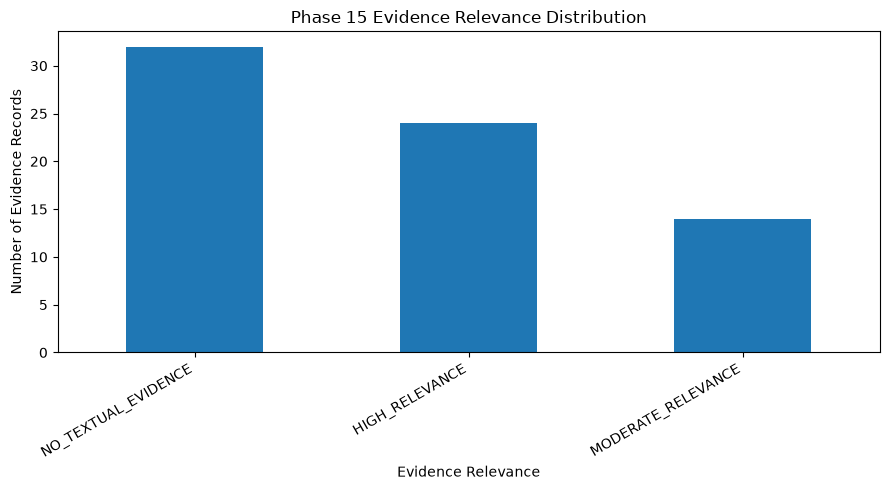

Saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase15\visualizations\evidence_relevance_distribution.png


In [27]:
# ============================================================
# PHASE 15 — CELL 24
# Evidence relevance distribution
# ============================================================

counts = (
    df["evidence_relevance"]
    .value_counts()
)

plt.figure(figsize=(9, 5))

counts.plot(
    kind="bar"
)

plt.title(
    "Phase 15 Evidence Relevance Distribution"
)

plt.xlabel(
    "Evidence Relevance"
)

plt.ylabel(
    "Number of Evidence Records"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

relevance_plot = (
    VIS_DIR
    / "evidence_relevance_distribution.png"
)

plt.savefig(
    relevance_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(relevance_plot)

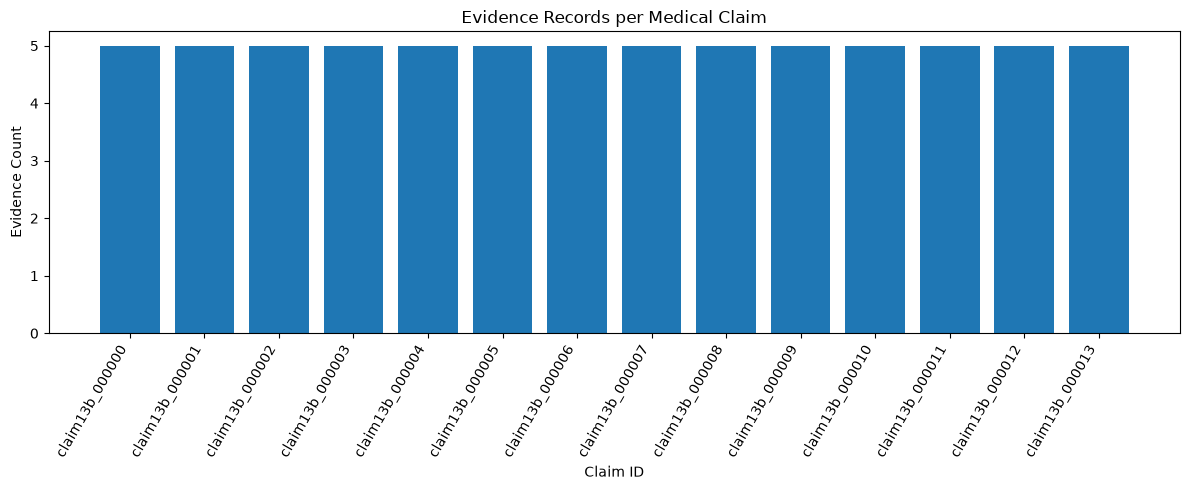

Saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase15\visualizations\evidence_per_claim.png


In [28]:
# ============================================================
# PHASE 15 — CELL 25
# Evidence count per claim
# ============================================================

plot_df = (
    claim_explanations_df
    .sort_values(
        "evidence_count",
        ascending=False
    )
)

plt.figure(figsize=(12, 5))

plt.bar(
    plot_df["claim_id"].astype(str),
    plot_df["evidence_count"]
)

plt.title(
    "Evidence Records per Medical Claim"
)

plt.xlabel(
    "Claim ID"
)

plt.ylabel(
    "Evidence Count"
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()

claim_evidence_plot = (
    VIS_DIR
    / "evidence_per_claim.png"
)

plt.savefig(
    claim_evidence_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(claim_evidence_plot)

Evidence source counts:


evidence_source
PubMed    38
WHO       32
Name: count, dtype: int64

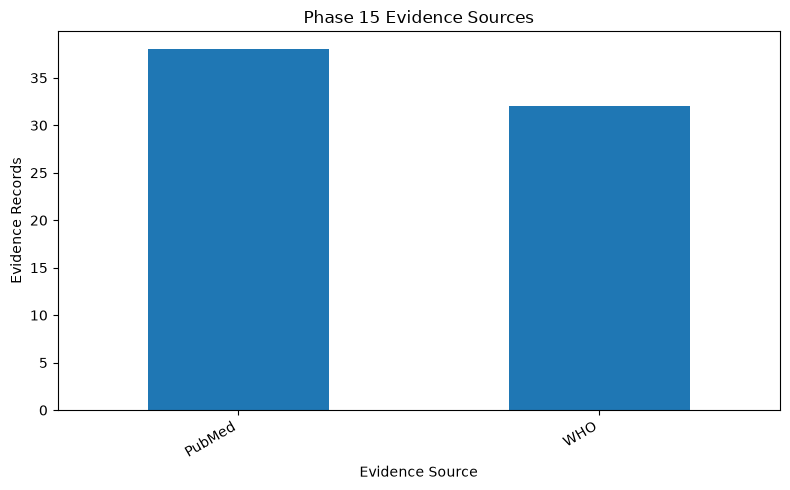

Saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase15\visualizations\evidence_source_distribution.png


In [29]:
# ============================================================
# PHASE 15 — CELL 26
# Evidence source distribution
# ============================================================

source_counts = (
    df["evidence_source"]
    .value_counts()
)

print("Evidence source counts:")
display(source_counts)

plt.figure(figsize=(8, 5))

source_counts.plot(
    kind="bar"
)

plt.title(
    "Phase 15 Evidence Sources"
)

plt.xlabel(
    "Evidence Source"
)

plt.ylabel(
    "Evidence Records"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

source_plot = (
    VIS_DIR
    / "evidence_source_distribution.png"
)

plt.savefig(
    source_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(source_plot)

In [30]:
# ============================================================
# PHASE 15 — CELL 27
# Claim-level relevance summary
# ============================================================

claim_relevance_summary = (
    df.groupby("claim_id")
    .agg(
        evidence_count=(
            "evidence_id",
            "count"
        ),

        best_relevance=(
            "evidence_score",
            "max"
        ),

        mean_relevance=(
            "evidence_score",
            "mean"
        ),

        high_relevance_count=(
            "evidence_relevance",
            lambda x: (
                x == "HIGH_RELEVANCE"
            ).sum()
        ),

        moderate_relevance_count=(
            "evidence_relevance",
            lambda x: (
                x == "MODERATE_RELEVANCE"
            ).sum()
        ),

        low_relevance_count=(
            "evidence_relevance",
            lambda x: (
                x == "LOW_RELEVANCE"
            ).sum()
        ),

        source_count=(
            "evidence_source",
            "nunique"
        ),
    )
    .reset_index()
)

display(
    claim_relevance_summary
)

,claim_id,evidence_count,best_relevance,mean_relevance,high_relevance_count,moderate_relevance_count,low_relevance_count,source_count
0,claim13b_000000,5,0.8571,0.57142,3,1,0,2
1,claim13b_000001,5,0.0000,0.00000,0,0,0,1
2,claim13b_000002,5,0.7500,0.65000,3,2,0,1
3,claim13b_000003,5,0.0000,0.00000,0,0,0,1
4,claim13b_000004,5,0.0000,0.00000,0,0,0,1
5,claim13b_000005,5,1.0000,0.60000,1,4,0,1
6,claim13b_000006,5,0.7500,0.75000,5,0,0,1
7,claim13b_000007,5,0.8571,0.57142,3,1,0,2
8,claim13b_000008,5,0.0000,0.00000,0,0,0,1
9,claim13b_000009,5,0.7500,0.65000,3,2,0,1


In [31]:
# ============================================================
# PHASE 15 — CELL 28
# Save claim relevance summary
# ============================================================

CLAIM_RELEVANCE_CSV = (
    METRICS_DIR
    / "claim_relevance_summary.csv"
)

claim_relevance_summary.to_csv(
    CLAIM_RELEVANCE_CSV,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(CLAIM_RELEVANCE_CSV)

Saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase15\metrics\claim_relevance_summary.csv


In [32]:
# ============================================================
# PHASE 15 — CELL 29
# Generate Phase 15 report
# ============================================================

REPORT_FILE = (
    REPORTS_DIR
    / "phase15_report.txt"
)

total_claims = len(
    claim_explanations_df
)

total_evidence = len(df)

claims_with_evidence = (
    claim_explanations_df[
        "evidence_count"
    ] > 0
).sum()

claims_without_evidence = (
    claim_explanations_df[
        "evidence_count"
    ] == 0
).sum()

overclaiming_count = (
    claim_explanations_df[
        "quality_flags"
    ]
    .str.contains(
        "OVERCLAIMING",
        na=False
    )
).sum()

with open(
    REPORT_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "PHASE 15 — EXPLAINABILITY REPORT\n"
    )

    f.write(
        "=" * 70 + "\n\n"
    )

    f.write(
        f"Total claims: {total_claims}\n"
    )

    f.write(
        f"Total evidence records: {total_evidence}\n"
    )

    f.write(
        f"Claims with evidence: "
        f"{claims_with_evidence}\n"
    )

    f.write(
        f"Claims without evidence: "
        f"{claims_without_evidence}\n"
    )

    f.write(
        f"Overclaiming flags: "
        f"{overclaiming_count}\n\n"
    )

    f.write(
        "Evidence relevance distribution:\n"
    )

    for category, count in (
        df["evidence_relevance"]
        .value_counts()
        .items()
    ):

        f.write(
            f"  {category}: {count}\n"
        )

    f.write("\nEvidence sources:\n")

    for source, count in (
        df["evidence_source"]
        .value_counts()
        .items()
    ):

        f.write(
            f"  {source}: {count}\n"
        )

    f.write(
        "\nQuality summary:\n"
    )

    for key, value in quality_summary.items():

        f.write(
            f"  {key}: {value}\n"
        )

    f.write(
        "\nIMPORTANT LIMITATION:\n"
    )

    f.write(
        "Phase 15 explanations describe the relationship "
        "between extracted claims and retrieved evidence. "
        "The relevance score is a textual retrieval measure "
        "and does not independently establish whether a "
        "medical claim is true or false.\n"
    )

print("Report saved:")
print(REPORT_FILE)

Report saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase15\reports\phase15_report.txt


In [33]:
# ============================================================
# PHASE 15 — CELL 30
# Final artifact check
# ============================================================

expected_files = [

    MANIFEST_DIR
    / "claim_level_explanations.csv",

    MANIFEST_DIR
    / "claim_level_explanations.jsonl",

    MANIFEST_DIR
    / "evidence_level_explanations.csv",

    METRICS_DIR
    / "explanation_statistics.csv",

    METRICS_DIR
    / "quality_summary.csv",

    METRICS_DIR
    / "claim_relevance_summary.csv",

    VIS_DIR
    / "evidence_relevance_distribution.png",

    VIS_DIR
    / "evidence_per_claim.png",

    VIS_DIR
    / "evidence_source_distribution.png",

    REPORT_FILE,
]

print("=" * 75)
print("PHASE 15 FINAL ARTIFACT CHECK")
print("=" * 75)

all_exist = True

for file_path in expected_files:

    if file_path.exists():

        print("✓", file_path)

    else:

        print("✗", file_path)

        all_exist = False


json_files = list(
    EXPLANATIONS_DIR.glob("*.json")
)

print()
print(
    "Individual claim JSON files:",
    len(json_files)
)

print(
    "Expected claim JSON files:",
    len(claim_explanations_df)
)

print(
    "Total claims:",
    len(claim_explanations_df)
)

print(
    "Total evidence records:",
    len(df)
)

print(
    "Claims with evidence:",
    (
        claim_explanations_df[
            "evidence_count"
        ] > 0
    ).sum()
)

print(
    "Claims without evidence:",
    (
        claim_explanations_df[
            "evidence_count"
        ] == 0
    ).sum()
)

print(
    "Overclaiming flags:",
    (
        claim_explanations_df[
            "quality_flags"
        ]
        .str.contains(
            "OVERCLAIMING",
            na=False
        )
    ).sum()
)

print()

if (
    all_exist
    and len(json_files) == len(
        claim_explanations_df
    )
):
    print(
        "✓ PHASE 15 COMPLETED SUCCESSFULLY"
    )

else:
    print(
        "✗ PHASE 15 IS NOT COMPLETE."
    )

PHASE 15 FINAL ARTIFACT CHECK
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase15\manifests\claim_level_explanations.csv
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase15\manifests\claim_level_explanations.jsonl
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase15\manifests\evidence_level_explanations.csv
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase15\metrics\explanation_statistics.csv
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase15\metrics\quality_summary.csv
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase15\metrics\claim_relevance_summary.csv
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase15\visualizations\evidence_relevance_distribution.png
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase15\visualizations\evidence_per_claim.png
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase15\visualizations\eviden